# LangGraph Guide

## Build a Basic Chatbot with LangGraph (Graph API)

In [14]:
import os
from typing import Annotated
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from langchain_tavily import TavilySearch
from IPython.display import Image, display
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Load environment variables from .env file
load_dotenv()

True

In [4]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting it).
    messages: Annotated[list, add_messages]

In [5]:
# define the llm using any one of the following methods
llm = ChatGroq(name = "llama3-8b-8192", model = "llama3-8b-8192")
llm = init_chat_model("groq:llama3-8b-8192")

# Node functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(State)

# adding node
graph_builder.add_node("llm_chatbot", chatbot)
# adding edges
graph_builder.add_edge(START, "llm_chatbot")
# adding edges to the END node
graph_builder.add_edge("llm_chatbot", END)

# compile the graph
graph = graph_builder.compile()

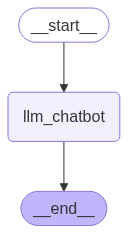

In [7]:
## Visualize the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error visualizing the graph: {e}")

In [13]:
response = graph.invoke({"messages": "Hi"})
response["messages"][-1].content

"Hi! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [14]:
for event in graph.stream({"messages": "Hi, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, I don't have emotions or feelings like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have! How about you? Is there something I can help you with?


## Chat Bot with Tools

In [8]:
tool  = TavilySearch(max_results = 2)
tools = [tool]
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'What is LangGraph? - IBM',
   'url': 'https://www.ibm.com/think/topics/langgraph',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. Nodes: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced decision-making by modeling c

In [9]:
# custom function
def multiply(a: int, b: int) -> int:
    """
    Multiplies two integers.

    Args:
        a (int): first integer
        b (int): second integer

    Returns:
        int: product of two integers

    """
    return a * b

In [10]:
tools = [tool, multiply]

In [11]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x00000218716C8730>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000218716C9D50>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list 

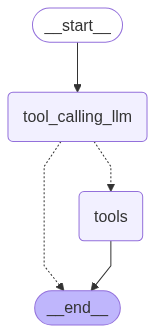

In [18]:
## State graph
# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

# display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# activate the web search tool
response = graph.invoke({"messages": "What is the recent AI news?"})
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2025/06/20/mira-muratis-thinking-machines-lab-closes-on-2b-at-10b-valuation/", "title": "Mira Murati’s Thinking Machines Lab closes on $2B at $10B valuation - TechCrunch", "score": 0.6862234, "published_date": "Fri, 20 Jun 2025 21:59:33 GMT", "content": "Enterprise \\n### Workhelix taps years of research to help enterprises figure out where to apply AI\\n\\n       Rebecca Szkutak\\n\\n Feb 27, 2025\\n\\nLatest in AI\\n------------\\n\\nSee More\\n\\n   \\nImage 9\\n\\nIn Brief \\n### Mira Murati’s Thinking Machines Lab closes on $2B at $10B valuation\\n\\n       Rebecca Bellan\\n\\n 11 seconds ago\\n\\n   \\nImage 10: Cluely founder Roy Lee party invitation video\\n\\nAI \\n### Cluely, a startup that helps ‘cheat on everything,’ raises $15M from a16z\\n\\n       Marina Temkin\\n\\n 53 minutes ago", "raw_content": null}, {"url": "https://www.theverge.com/co

In [21]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (70wn18tgh)
 Call ID: 70wn18tgh
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2025/06/20/mira-muratis-thinking-machines-lab-closes-on-2b-at-10b-valuation/", "title": "Mira Murati’s Thinking Machines Lab closes on $2B at $10B valuation - TechCrunch", "score": 0.6862234, "published_date": "Fri, 20 Jun 2025 21:59:33 GMT", "content": "Enterprise \n### Workhelix taps years of research to help enterprises figure out where to apply AI\n\n       Rebecca Szkutak\n\n Feb 27, 2025\n\nLatest in AI\n-----

In [ ]:
# activate the custom tool
response = graph.invoke({"messages": "What is 2 multiply 3?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply 3?
================================== Ai Message ==================================
Tool Calls:
  multiply (t4hw727zn)
 Call ID: t4hw727zn
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [23]:
response = graph.invoke({"messages": "What is 5 multiplied by 6? And, then multiply 10."})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 6? And, then multiply 10.
================================== Ai Message ==================================
Tool Calls:
  multiply (d3cmn1hpz)
 Call ID: d3cmn1hpz
  Args:
    a: 5
    b: 6
  multiply (4jd0ymj5z)
 Call ID: 4jd0ymj5z
  Args:
    a: 30
    b: 10
================================= Tool Message =================================
Name: multiply

30
================================= Tool Message =================================
Name: multiply

300


In [24]:
response = graph.invoke({"messages": "Give me the recent AI news and then multiply 5 by 10."})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (gcbcpjy71)
 Call ID: gcbcpjy71
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
  multiply (1wde6tgny)
 Call ID: 1wde6tgny
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2025/06/20/mira-muratis-thinking-machines-lab-closes-on-2b-at-10b-valuation/", "title": "Mira Murati’s Thinking Machines Lab closes on $2B at $10B valuation - TechCrunch", "score": 0.6862234, "published_date": "Fri, 20 Jun 2025 21:59:33 GMT", "content": "Enterprise \n### Workhelix taps years of research to help enterprise

### ReAct Agent Architecture

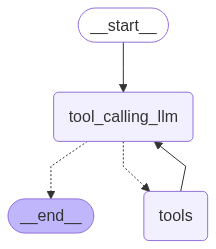

In [25]:
## Add the LLM to the Agentic Graph
# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")


## compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
response = graph.invoke({"messages": "Give me the recent AI news and then multiply 5 by 10."})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (a85ywx7cd)
 Call ID: a85ywx7cd
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "title": "Latest AI Breakthroughs and News: May-June 2025 - Crescendo.ai", "content": "**Date:** June 20, 2025  \n**Summary:** A new four-legged AI robot developed in China can play badminton with humans, reacting in real-time to shots. The quadruped robot uses vision, sensor data, and machine learning to anticipate movements and adjust its strategy. Researchers say this

## Add memory to the Agentic Graph

In [ ]:
## Add the LLM to the Agentic Graph
# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")


## compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))